In [1]:
import numpy as np
import pandas as pd
import sklearn.naive_bayes as naive_bayes

In [2]:
train_imdb = pd.read_csv("movie_review_train.csv")
train_imdb.head()

,class,text
0,Pos,a common complaint amongst film critics is ...
1,Pos,whew this film oozes energy the kind of b...
2,Pos,steven spielberg s amistad which is bas...
3,Pos,he has spent his entire life in an awful litt...
4,Pos,being that it is a foreign language film with...


In [3]:
train_imdb["class"].value_counts()

class
Pos    800
Neg    800
Name: count, dtype: int64

In [5]:
train_imdb["class"] = train_imdb["class"].map({"Neg": 0, "Pos": 1})

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(stop_words="english")

In [7]:
X_train, y_train = train_imdb["text"], train_imdb["class"]

In [8]:
vec.fit(X_train)

CountVectorizer(stop_words='english')

In [10]:
print(vec.vocabulary_, "\n", len(vec.vocabulary_))

{'common': 6284, 'complaint': 6360, 'film': 11832, 'critics': 7378, 'aren': 1810, 'literate': 18603, 'scripts': 27918, 'available': 2319, 'quiz': 25250, 'gives': 13262, 'signs': 28809, 'hope': 15074, 'art': 1928, 'writing': 35521, 'isn': 16771, 'dead': 7904, 'hollywood': 14963, 'need': 21281, 'look': 18770, 'independent': 15988, 'films': 11851, 'thoughtful': 32060, 'content': 6771, 'paul': 23045, 'attanasio': 2173, 'script': 27912, 'takes': 31486, 'tepid': 31839, 'thriller': 32090, 'scandals': 27629, 'late': 18017, '50s': 313, 'delivers': 8215, 'telling': 31765, 'parable': 22815, 'emptiness': 10340, 'post': 24178, 'war': 34707, 'american': 1334, 'dream': 9554, 'golden': 13449, 'bubble': 4285, 'surrounds': 31156, 'protects': 24849, 'tv': 33056, 'networks': 21378, 'sponsors': 29948, 'riddled': 26743, 'symbols': 31370, '58': 328, 'chrysler': 5614, 'radio': 25314, 'announcement': 1534, 'sputnik': 30053, 'heavy': 14532, 'handed': 14185, 'deft': 8137, 'direction': 8797, 'robert': 26913, 'red

In [11]:
len(vec.vocabulary_.keys())

35858

In [12]:
train_imdb.head(10)

,class,text
0,1,a common complaint amongst film critics is ...
1,1,whew this film oozes energy the kind of b...
2,1,steven spielberg s amistad which is bas...
3,1,he has spent his entire life in an awful litt...
4,1,being that it is a foreign language film with...
5,1,when i first heard of contact the hype was ...
6,1,you ve got to love disney no matter what t...
7,1,with three pre to mid teen children and an a...
8,1,i hate to burst your bubble but after all t...
9,1,susan granger s review of osmosis jones ...


In [13]:
train_imdb.tail(10)

,class,text
1590,0,man this was one wierd movie similar to ...
1591,0,the king and i a warner brothers animated ...
1592,0,synopsis cro magnon ayla loses her mother t...
1593,0,salaries of hollywood top actors are getting ...
1594,0,movies like six days seven nights make me m...
1595,0,if anything stigmata should be taken as...
1596,0,john boorman s zardoz is a goofy cinemati...
1597,0,the kids in the hall are an acquired taste ...
1598,0,there was a time when john carpenter was a gr...
1599,0,two party guys bob their heads to haddaway s ...


In [63]:
vec = CountVectorizer(stop_words="english", min_df=0.03, max_df=0.8)
vec.fit(X_train)

CountVectorizer(max_df=0.8, min_df=0.03, stop_words='english')

In [64]:
len(vec.vocabulary_)

1643

In [65]:
X_train_transformed = vec.transform(X_train)

In [66]:
print(X_train_transformed[:10])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1320 stored elements and shape (10, 1643)>
  Coords	Values
  (0, 4)	1
  (0, 59)	2
  (0, 72)	1
  (0, 78)	1
  (0, 81)	1
  (0, 99)	3
  (0, 101)	1
  (0, 192)	1
  (0, 211)	1
  (0, 213)	1
  (0, 220)	1
  (0, 264)	2
  (0, 287)	1
  (0, 316)	1
  (0, 323)	1
  (0, 328)	1
  (0, 340)	1
  (0, 342)	1
  (0, 357)	1
  (0, 386)	1
  (0, 413)	2
  (0, 445)	2
  (0, 464)	1
  (0, 503)	1
  (0, 506)	1
  :	:
  (9, 887)	1
  (9, 933)	1
  (9, 948)	1
  (9, 1011)	1
  (9, 1048)	1
  (9, 1052)	1
  (9, 1073)	1
  (9, 1168)	1
  (9, 1169)	1
  (9, 1194)	1
  (9, 1200)	1
  (9, 1207)	1
  (9, 1236)	1
  (9, 1238)	1
  (9, 1240)	1
  (9, 1254)	1
  (9, 1375)	1
  (9, 1429)	1
  (9, 1481)	1
  (9, 1509)	1
  (9, 1511)	1
  (9, 1577)	1
  (9, 1592)	1
  (9, 1596)	1
  (9, 1630)	1


In [67]:
dir(X_train_transformed)

['T',
 '__abs__',
 '__add__',
 '__array_priority__',
 '__bool__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__div__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__idiv__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__le__',
 '__len__',
 '__lt__',
 '__matmul__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__nonzero__',
 '__pow__',
 '__radd__',
 '__rdiv__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmatmul__',
 '__rmul__',
 '__round__',
 '__rsub__',
 '__rtruediv__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__sub__',
 '__subclasshook__',
 '__truediv__',
 '__weakref__',
 '_add_dense',
 '_add_sparse',
 '_allow_nd',
 '_arg_min_or_max',
 '_arg_min_or_max_axis',
 '_ascontainer',
 '_asfptype',
 '_asindices',
 '_binopt',
 '_broadcast_to',
 '_bsr_container',
 '_container',
 '_coo_containe

In [68]:
X_train_transformed.shape

(1600, 1643)

In [21]:
X_train_transformed.get_shape()

(1600, 35858)

In [81]:
x = pd.DataFrame(X_train_transformed.toarray())

In [85]:
sum(x)

1348903

In [75]:
X_train_transformed.toarray().sum()

np.int64(290807)

In [87]:
test_docs = pd.read_csv("movie_review_test.csv")

In [88]:
test_docs.head()

,class,text
0,Pos,films adapted from comic books have had plent...
1,Pos,every now and then a movie comes along from a...
2,Pos,you ve got mail works alot better than it des...
3,Pos,jaws is a rare film that grabs your atte...
4,Pos,moviemaking is a lot like being the general m...


In [89]:
test_docs["class"] = test_docs["class"].map({"Neg": 0, "Pos": 1})

In [90]:
X_test, y_test = test_docs["text"], test_docs["class"]
X_test_transformed = vec.transform(X_test)

In [112]:
X_test_transformed

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 51663 stored elements and shape (400, 1643)>

In [98]:
# Using Multinomial classifier

mnb = naive_bayes.BernoulliNB()

# fit

mnb.fit(X_train_transformed, y_train)

y_test_predict = mnb.predict(X_test_transformed)

In [99]:
y_test_predict[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 0, 1])

In [32]:
multi_prob = mnb.predict_proba(X_test_transformed)
multi_prob

array([[9.99815544e-01, 1.84456400e-04],
       [1.80431723e-08, 9.99999982e-01],
       [2.93597323e-04, 9.99706403e-01],
       [1.37891062e-22, 1.00000000e+00],
       [9.99992587e-01, 7.41255840e-06],
       [2.52436000e-40, 1.00000000e+00],
       [3.31873454e-38, 1.00000000e+00],
       [1.62120574e-04, 9.99837879e-01],
       [5.64657141e-04, 9.99435343e-01],
       [2.27934669e-17, 1.00000000e+00],
       [6.45031025e-11, 1.00000000e+00],
       [3.30466641e-16, 1.00000000e+00],
       [3.56839515e-15, 1.00000000e+00],
       [1.01922028e-19, 1.00000000e+00],
       [4.52327526e-07, 9.99999548e-01],
       [7.43064598e-09, 9.99999993e-01],
       [3.80502907e-04, 9.99619497e-01],
       [6.69381494e-24, 1.00000000e+00],
       [3.16041572e-07, 9.99999684e-01],
       [9.99998734e-01, 1.26589019e-06],
       [1.21615068e-04, 9.99878385e-01],
       [1.56937693e-04, 9.99843062e-01],
       [1.00000000e+00, 1.86510166e-10],
       [1.58722898e-31, 1.00000000e+00],
       [3.260045

In [100]:
from sklearn import metrics

metrics.accuracy_score(y_true=y_test, y_pred=y_test_predict)

0.79

In [101]:
metrics.confusion_matrix(y_test, y_test_predict)

array([[177,  23],
       [ 61, 139]])

In [35]:
metrics.roc_auc_score(y_test, y_test_predict)

np.float64(0.7950000000000002)

In [36]:
confusion = metrics.confusion_matrix(y_test, y_test_predict)
tn = confusion[0, 0]
fp = confusion[0, 1]
fn = confusion[1, 0]
tp = confusion[1, 1]

In [37]:
# Sensitivity
sensitivity = float(
    tp / float(tp + fn)
)  # Out of all positive reviews, how many are actually positive?
print("Sensitivity:", sensitivity)

Sensitivity: 0.78


In [38]:
# specifity
specificity = float(tn / float(tn + fp))
print("Specificity:", specificity)

Specificity: 0.81


In [39]:
# Precision,recall and f1 score
print("Precision Score:", metrics.precision_score(y_test, y_test_predict))
print("Recall Score:", metrics.recall_score(y_test, y_test_predict))
print("F1 Score:", metrics.f1_score(y_test, y_test_predict))

Precision Score: 0.8041237113402062
Recall Score: 0.78
F1 Score: 0.7918781725888325


In [40]:
# Area Under Curve
false_positive_rate, true_positive_rate, thresholds = metrics.roc_curve(
    y_test, multi_prob[:, 1]
)
roc_auc = metrics.auc(false_positive_rate, true_positive_rate)
print("AUC:", roc_auc)

AUC: 0.8668375


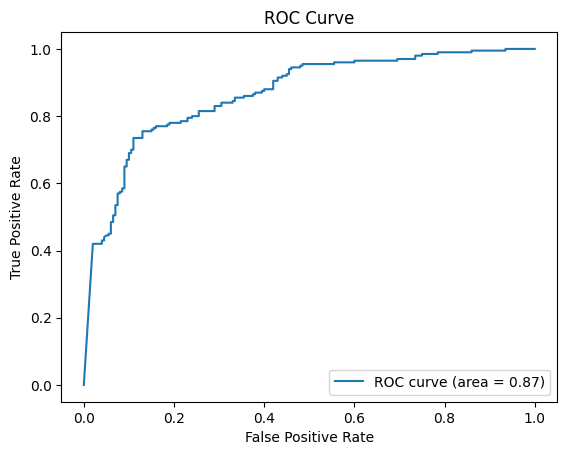

In [41]:
import matplotlib.pyplot as plt

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.plot(
    false_positive_rate, true_positive_rate, label="ROC curve (area = %0.2f)" % roc_auc
)
plt.legend(loc="lower right")
plt.show()

In [42]:
len(vec.vocabulary_)

35858

In [43]:
tpr = tp / (tp + fn)
tpr

np.float64(0.78)

In [44]:
fpr = fp / (tn + fp)
fpr

np.float64(0.19)

In [45]:
1 - specificity

0.18999999999999995

In [46]:
sensitivity

0.78

In [47]:
roc_auc

np.float64(0.8668375)

In [60]:
vec = CountVectorizer(stop_words="english", min_df=0.03, max_df=0.8)
vec.fit(X_train)

CountVectorizer(max_df=0.8, min_df=0.03, stop_words='english')

In [61]:
len(vec.vocabulary_)

1643

In [54]:
sum(vec.vocabulary_.values())

1275

In [51]:
X_train.head()

0     a common complaint amongst film critics is   ...
1     whew   this film oozes energy   the kind of b...
2     steven spielberg s   amistad     which is bas...
3     he has spent his entire life in an awful litt...
4     being that it is a foreign language film with...
Name: text, dtype: object

In [55]:
df = pd.read_csv("movie_review_train.csv")

In [57]:
X, y = df["text"], df["class"]

In [58]:
vec = CountVectorizer(stop_words="english", min_df=0.3, max_df=0.8)
vec.fit(X)

CountVectorizer(max_df=0.8, min_df=0.3, stop_words='english')

In [59]:
len(vec.vocabulary_)

51